In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

## Credit Card Dataset

In [168]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


First lets undersample since this is a fraud dataset

In [169]:
X = df.drop(columns='Class')

In [170]:
y = df['Class']

In [171]:
print("Original dataset shape:", Counter(y))

Original dataset shape: Counter({0: 284315, 1: 492})


In [172]:
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Resampled dataset shape: Counter({0: 492, 1: 492})


The features are not that clear in this dataset, so we can first check for correlations in the data

<Axes: >

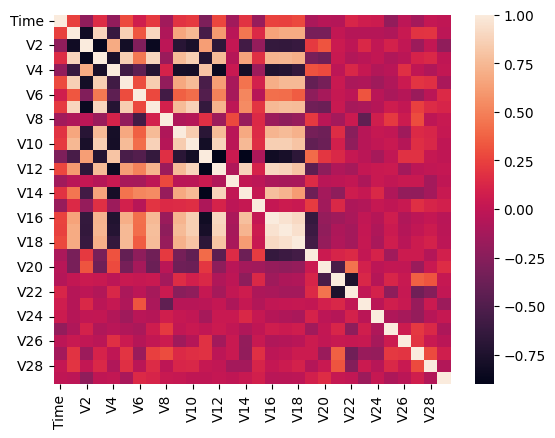

In [173]:
sns.heatmap(X_resampled.corr())

In [174]:
X = sm.add_constant(X) 
model = sm.OLS(y, X) 
results = model.fit() 
print(results.params) 

const     1.513407e-03
Time     -4.394263e-09
V1       -1.928620e-03
V2        2.869009e-03
V3       -5.094224e-03
V4        3.773967e-03
V5       -2.331491e-03
V6       -1.659706e-03
V7       -6.845068e-03
V8        8.386991e-04
V9       -3.623931e-03
V10      -8.099291e-03
V11       6.250217e-03
V12      -1.078732e-02
V13      -2.139852e-04
V14      -1.319082e-02
V15      -2.276118e-04
V16      -9.303530e-03
V17      -1.599623e-02
V18      -5.576934e-03
V19       1.905002e-03
V20       2.823245e-04
V21       2.039853e-03
V22       2.469478e-04
V23       1.605846e-04
V24      -5.158609e-04
V25       3.340582e-04
V26       3.776389e-04
V27       1.678495e-03
V28       1.138270e-03
Amount    7.138858e-06
dtype: float64


In [175]:
y_pred = results.predict(X)

Text(0, 0.5, 'Y True')

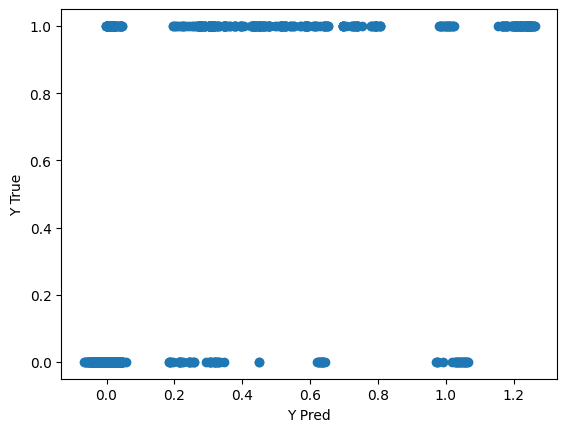

In [176]:
plt.scatter(y_pred, y)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [177]:
mean_absolute_error(y_true=y, y_pred=y_pred)

0.0033740975340107947

In [178]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [179]:
vif_data

,Feature,VIF
0,const,10.065370
1,Time,1.879865
2,V1,1.651908
3,V2,4.422390
4,V3,1.877342
5,V4,1.138061
6,V5,2.859316
7,V6,1.571530
8,V7,2.929040
9,V8,1.131633


The model overpredicts a lot of negative cases, and underpredicts a lot of positive cases. There are likely non-linear patterns in the data

There is not too much multicolinearity, aside from Amount 

Attempting Polynomial Terms

In [180]:
df_X_with_square = pd.concat((X, (X**2).rename(columns = {f"{var}": f"{var}_2" for var in X.columns})), axis = 1) 
df_X_with_square = sm.add_constant(df_X_with_square) 
model = sm.OLS(y, df_X_with_square) 
results = model.fit() 
print(results.params)

const       5.054428e-03
Time       -1.973970e-08
V1         -5.826360e-03
V2          4.481218e-03
V3         -1.236083e-02
                ...     
V25_2       9.106472e-06
V26_2       1.232904e-03
V27_2       3.494659e-05
V28_2      -2.255337e-05
Amount_2    8.350606e-10
Length: 62, dtype: float64


In [181]:
y_pred = results.predict(df_X_with_square)

Text(0, 0.5, 'Y True')

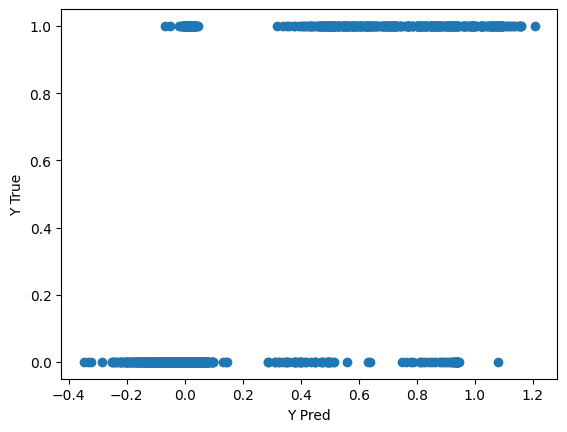

In [182]:
plt.scatter(y_pred, y)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [183]:
mean_absolute_error(y_true=y, y_pred=y_pred)

0.005065552998079394

This model is actually a bit worse

In [184]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df_X_with_square.columns
vif_data["VIF"] = [variance_inflation_factor(df_X_with_square.values, i) for i in range(df_X_with_square.shape[1])]

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [185]:
len(vif_data.sort_values(by="VIF")[vif_data['VIF'] > 5])

C:\Users\caleb\AppData\Local\Temp\ipykernel_25332\2692098991.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(vif_data.sort_values(by="VIF")[vif_data['VIF'] > 5])


21

21 of the features have VIF > 5, showing multicollinearity. Lets drop them

In [186]:
vif_data = vif_data[vif_data['VIF'] < 5]

In [187]:
len(vif_data['Feature'].values)

41

In [188]:
df_X_with_square_new = df_X_with_square[vif_data['Feature'].values]

In [189]:
df_X_with_square_new

,const,V4,V6,V7,V8,V9,V10,V11,V12,V13,...,V15_2,V18_2,V19_2,V22_2,V23_2,V24_2,V25_2,V26_2,V27_2,V28_2
0,1.0,1.378155,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,...,2.155544,0.000665,0.163210,0.077194,0.012204,0.004479,0.016522,0.035764,0.017838,0.000443
1,1.0,0.448154,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,...,0.403934,0.033621,0.021253,0.407902,0.010259,0.115496,0.027946,0.015849,0.000081,0.000217
2,1.0,0.379780,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,...,5.503082,0.014728,5.115998,0.595489,0.827031,0.475108,0.107349,0.019348,0.003064,0.003570
3,1.0,-0.863291,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,...,0.398689,3.864271,1.519357,0.000028,0.036222,1.381977,0.419096,0.049252,0.003934,0.003777
4,1.0,0.403034,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,...,0.030667,0.001459,0.645591,0.637249,0.018895,0.019956,0.042440,0.252297,0.048146,0.046291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.0,-2.066656,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,...,0.854624,0.260745,0.466379,0.012513,1.029169,0.259436,2.064414,0.062517,0.890478,0.678533
284803,1.0,-0.738589,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,...,1.357064,1.491278,2.388744,0.854485,0.000155,1.032715,0.367993,0.156227,0.004688,0.002865
284804,1.0,-0.557828,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,...,1.766995,0.156541,0.333220,0.334349,0.001406,0.409771,0.070621,0.007634,0.000020,0.000705
284805,1.0,0.689799,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,...,3.851654,1.240953,8.397528,0.640078,0.026666,0.015180,0.323942,0.298846,0.011842,0.010927


In [190]:
model = sm.OLS(y, df_X_with_square_new) 
results = model.fit() 
print(results.params)

const      0.000738
V4         0.003028
V6        -0.000910
V7        -0.005078
V8         0.001798
V9        -0.003900
V10       -0.007526
V11        0.004422
V12       -0.007634
V13       -0.000570
V14       -0.009517
V15       -0.000024
V16       -0.008143
V17       -0.013777
V18       -0.005379
V19        0.001576
V20        0.000024
V21        0.002189
V22        0.000093
V23       -0.000034
V24       -0.001335
V25       -0.000077
V26        0.001014
V27        0.002329
V28        0.002540
const_2    0.000738
V4_2       0.000210
V9_2       0.000590
V11_2     -0.002170
V13_2      0.000211
V14_2      0.002680
V15_2     -0.000735
V18_2     -0.001408
V19_2     -0.000110
V22_2      0.001539
V23_2      0.000019
V24_2     -0.000809
V25_2     -0.000301
V26_2     -0.000333
V27_2      0.000234
V28_2     -0.000125
dtype: float64


In [191]:
y_pred = results.predict(df_X_with_square_new)

Text(0, 0.5, 'Y True')

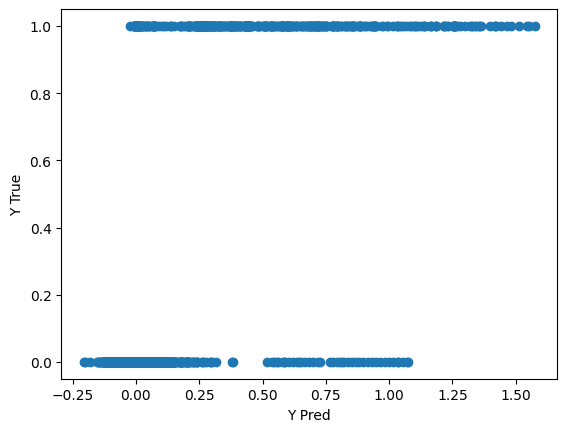

In [192]:
plt.scatter(y_pred, y)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [193]:
mean_absolute_error(y_true=y, y_pred=y_pred)

0.006337391222183026

### Conclusions

In the OLS model, we only see Amount with severe multicollinearity (12.116701) through VIF. Next is V2 with 4.422390 VIF. I calculate the OLS MSE as 0.0033740975340107947

Next I performed polynomial interaction terms, doubling from 31 to 62 features. I calculate the MSE as 0.005065552998079394. When checking for VIF, we see 21 features with VIF > 5, so I dropped them, leaving 41 features total. Some of the independent variables highly correlate with each other, making it difficult for OLS to isolate the individual effect of each predictor.

Now I run OLS again on the 41 features and get a MSE of 0.006337391222183026

As we can see, the model did not improve with more features, simpler was better. The polynomial terms added noise. Also, removing the multicollinear features degraded performance further. This could be due to the polynomial terms introducing overfitting or highly unstable coefficient estimates.

To handle the multicollinearity, we can try regularization techniques like Ridge

## IBM Dataset

In [194]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ibm_hi_small_trans_cleaned.csv')
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,3697.340000,0,3697.340000,3697.340000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,0.010000,0,0.010000,0.010000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,14675.570000,0,14675.570000,14675.570000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,2806.970000,0,2806.970000,2806.970000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,36682.970000,0,36682.970000,36682.970000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,0.154978,0,3107.386389,3107.386389,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,0.108128,0,2168.020464,2168.020464,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,0.004988,0,100.011894,100.011894,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,0.038417,0,770.280058,770.280058,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [195]:
cols_to_drop = [c for c in df.columns if "Mean" in c or "Median" in c]
cols_to_drop.extend(['Timestamp', 'From Bank', 'To Bank', 'Account', 'Account.1'])
df.drop(columns=cols_to_drop, inplace=True)

In [196]:
df

,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,3697.340000,3697.340000,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0.010000,0.010000,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,14675.570000,14675.570000,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2806.970000,2806.970000,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,36682.970000,36682.970000,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0.154978,0.154978,0,3107.386389,3107.386389,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0.108128,0.108128,0,2168.020464,2168.020464,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0.004988,0.004988,0,100.011894,100.011894,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0.038417,0.038417,0,770.280058,770.280058,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [197]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


def clean_data(df_input):
    # 1. Create a copy to avoid modifying original data
    df_new = df_input.copy()

    # 2. Fix Numeric Multicollinarity: Drop redundant USD tracking columns
    # Keeping only USD values removes the 360-million VIF issue
    cols_to_drop = ["Amount Received", "Amount Paid"]
    df_new = df_new.drop(columns=[c for c in cols_to_drop if c in df_new.columns])

    # 3. Fix Dummy Variable Trap: Drop one column from each categorical group
    # We identify groups by splitting column names on the underscore '_'
    dummy_groups = [
        "Receiving Currency",
        "Payment Currency",
        "Payment Format",
    ]

    for group in dummy_groups:
        # Find all columns belonging to this specific categorical group
        group_cols = [c for c in df_new.columns if c.startswith(group)]
        if len(group_cols) > 1:
            # Drop the very first column of this group to serve as the baseline
            df_new = df_new.drop(columns=[group_cols[0]])
            print(f"Dropped baseline category to fix 'inf': {group_cols[0]}")

    # 4. Handle Constant Column (Ensure only one exists and it has variance)
    if "const" in df_new.columns:
        # If const is all zeros or broken from scaling, reset it
        df_new = df_new.drop(columns=["const"])

    df_new.to_csv('ibm_hi_small_trans_cleaned_semester3.csv', index=False)

    # # 5. Calculate clean VIF Data
    # vif_data = pd.DataFrame()
    # vif_data["Feature"] = X.columns
    # vif_data["VIF"] = [
    #     variance_inflation_factor(X.values, i) for i in range(X.shape[1])
    # ]

    # return vif_data, X


# --- HOW TO RUN IT ---
# Assuming your current DataFrame is named 'my_vif_df'
# clean_vif, clean_X = clean_data_and_calculate_vif(my_vif_df)
# print(clean_vif)
clean_data(df)

Dropped baseline category to fix 'inf': Receiving Currency_Australian Dollar
Dropped baseline category to fix 'inf': Payment Currency_Australian Dollar
Dropped baseline category to fix 'inf': Payment Format_ACH


In [198]:
df = pd.read_csv('ibm_hi_small_trans_cleaned_semester3.csv')
df

,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,...,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0,3107.386389,3107.386389,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0,2168.020464,2168.020464,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0,100.011894,100.011894,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0,770.280058,770.280058,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


First lets undersample since this is a fraud dataset

In [199]:
X = df.drop(columns='Is Laundering')

In [200]:
y = df['Is Laundering']

In [201]:
print("Original dataset shape:", Counter(y))

Original dataset shape: Counter({0: 5073168, 1: 5177})


In [202]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.0137455 , -0.01388989, -0.17334858, ..., -0.1871525 ,
         2.75494448,  2.51907519],
       [-0.01389411, -0.01404096, -0.17334858, ..., -0.1871525 ,
        -0.36298372, -0.39697108],
       [-0.01330424, -0.01344133, -0.17334858, ..., -0.1871525 ,
         2.75494448,  2.51907519],
       ...,
       [-0.01389009, -0.01403687,  5.76872333, ..., -0.1871525 ,
        -0.36298372, -0.39697108],
       [-0.01386315, -0.01400949,  5.76872333, ..., -0.1871525 ,
        -0.36298372,  2.51907519],
       [-0.01366686, -0.01380994,  5.76872333, ..., -0.1871525 ,
        -0.36298372, -0.39697108]], shape=(5078345, 38))

In [203]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df

,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,Receiving Currency_Saudi Riyal,...,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,-0.013746,-0.013890,-0.173349,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,-0.172103,-0.32712,-0.761619,-0.593645,3.091385,-0.187152,2.754944,2.519075
1,-0.013894,-0.014041,-0.173349,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,-0.172103,-0.32712,1.312993,-0.593645,-0.323480,-0.187152,-0.362984,-0.396971
2,-0.013304,-0.013441,-0.173349,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,-0.172103,-0.32712,-0.761619,-0.593645,3.091385,-0.187152,2.754944,2.519075
3,-0.013781,-0.013926,-0.173349,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,-0.172103,-0.32712,-0.761619,-0.593645,3.091385,-0.187152,2.754944,2.519075
4,-0.012420,-0.012542,-0.173349,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,-0.172103,-0.32712,-0.761619,-0.593645,3.091385,-0.187152,2.754944,2.519075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,-0.013769,-0.013914,5.768723,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,5.810466,-0.32712,-0.761619,-0.593645,-0.323480,-0.187152,-0.362984,-0.396971
5078341,-0.013807,-0.013952,5.768723,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,5.810466,-0.32712,-0.761619,-0.593645,-0.323480,-0.187152,-0.362984,-0.396971
5078342,-0.013890,-0.014037,5.768723,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,5.810466,-0.32712,-0.761619,-0.593645,-0.323480,-0.187152,-0.362984,-0.396971
5078343,-0.013863,-0.014009,5.768723,-0.119538,-0.169211,-0.54775,-0.149506,-0.178823,-0.19826,-0.134299,...,-0.177557,-0.20962,5.810466,-0.32712,-0.761619,-0.593645,-0.323480,-0.187152,-0.362984,2.519075


In [204]:
rus = RandomUnderSampler(sampling_strategy=.2, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_scaled_df, y)

print("Resampled dataset shape:", Counter(y_resampled))

Resampled dataset shape: Counter({0: 25885, 1: 5177})


In [205]:
X_resampled = sm.add_constant(X_resampled) 
model = sm.OLS(y_resampled, X_resampled) 
results = model.fit() 
print(results.params) 

const                                 2.076450e+05
Amount_Received_USD                   3.680384e-01
Amount_Paid_USD                      -3.613914e-01
Receiving Currency_Bitcoin           -1.855232e-02
Receiving Currency_Brazil Real       -4.686437e-03
Receiving Currency_Canadian Dollar    1.746118e-02
Receiving Currency_Euro               6.788621e-02
Receiving Currency_Mexican Peso       1.566433e-02
Receiving Currency_Ruble              6.642786e-03
Receiving Currency_Rupee              9.050260e-03
Receiving Currency_Saudi Riyal        1.464986e-02
Receiving Currency_Shekel            -8.217038e-03
Receiving Currency_Swiss Franc        9.506976e-04
Receiving Currency_UK Pound           2.483383e-02
Receiving Currency_US Dollar          9.916748e-02
Receiving Currency_Yen                3.186883e-02
Receiving Currency_Yuan               5.180521e-02
Payment Currency_Bitcoin             -7.049847e+09
Payment Currency_Brazil Real          4.030512e-03
Payment Currency_Canadian Dolla

In [206]:
y_pred = results.predict(X_resampled)

Text(0, 0.5, 'Y True')

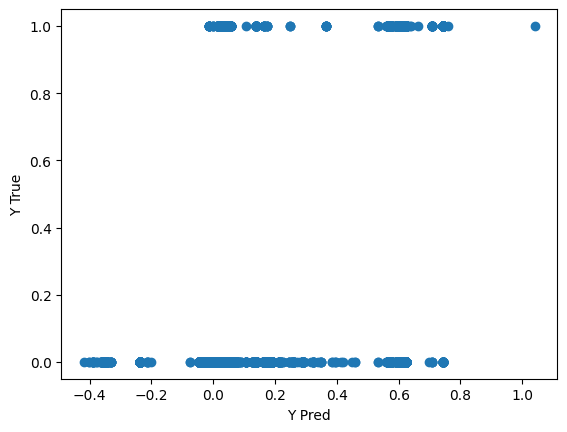

In [207]:
plt.scatter(y_pred, y_resampled)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [208]:
mean_absolute_error(y_true=y_resampled, y_pred=y_pred)

0.15827507730366167

In [209]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_resampled.columns
vif_data["VIF"] = [variance_inflation_factor(X_resampled.values, i) for i in range(X_resampled.shape[1])]

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [210]:
vif_data

,Feature,VIF
0,const,0.000000e+00
1,Amount_Received_USD,1.882177e+06
2,Amount_Paid_USD,1.882454e+06
3,Receiving Currency_Bitcoin,1.245072e+02
4,Receiving Currency_Brazil Real,8.840701e+01
5,Receiving Currency_Canadian Dollar,1.165521e+02
6,Receiving Currency_Euro,5.564388e+02
7,Receiving Currency_Mexican Peso,1.297524e+02
8,Receiving Currency_Ruble,1.342938e+02
9,Receiving Currency_Rupee,1.455121e+02


The inf on Bitcoin & Ruble:

Bitcoin: Payment Format_Bitcoin, Payment Currency_Bitcoin, and Receiving Currency_Bitcoin always happen at the exact same time. If someone pays via Bitcoin format, the currency is always Bitcoin. They are 100% identical vectors.

Ruble: Receiving Currency_Ruble and Payment Currency_Ruble are perfectly correlated, meaning every Ruble transaction in your dataset has the exact same sender and receiver currency. This is a limitation of the sample size or the dataset creation

In [211]:
# 1. Break the Amount Mirror: Keep only ONE transactional volume metric
# Drop 'Amount_Paid_USD' since it's identical to 'Amount_Received_USD'
if "Amount_Paid_USD" in X_resampled.columns:
    X_resampled = X_resampled.drop(columns=["Amount_Paid_USD"])
    print("Dropped: Amount_Paid_USD (Redundant with Amount_Received_USD)")

# 2. Break Cross-Variable Identity Traps (Bitcoin & Ruble overlap)
# Bitcoin format dictates Bitcoin currency. We only need one indicator.
cols_to_remove = [
    "Payment Format_Bitcoin",
    "Payment Currency_Bitcoin",
    "Payment Currency_Ruble",
]

X_resampled = X_resampled.drop(columns=[c for c in cols_to_remove if c in X.columns])
print(f"Dropped overlapping cross-variables: {cols_to_remove}")


# Identify all remaining currency features
recv_cols = [c for c in X_resampled.columns if c.startswith("Receiving Currency_")]
pay_cols = [c for c in X_resampled.columns if c.startswith("Payment Currency_")]

# Extract clean currency names present in both sets
# e.g., 'US Dollar', 'Euro'
currencies = [c.split("_")[1] for c in pay_cols]

# Reconstruct if a transaction required a Foreign Exchange (FX) conversion
# It's an FX transaction if Payment Currency != Receiving Currency
# We look across all currencies to find where they mismatch
fx_conditions = []
for curr in currencies:
    p_col = f"Payment Currency_{curr}"
    r_col = f"Receiving Currency_{curr}"

    if p_col in X_resampled.columns and r_col in X_resampled.columns:
        # If one is 1 and the other is 0, it's an FX transaction
        fx_conditions.append(X_resampled[p_col] != X_resampled[r_col])

# If any currency pair mismatched, Is_FX becomes 1
if fx_conditions:
    X_resampled["Is_FX"] = np.amax(np.column_stack(fx_conditions), axis=1).astype(int)
    print("Created feature: Is_FX")

# 4. Drop the redundant set of currency columns entirely
# Dropping 'Receiving Currency' eliminates the ~170 VIF inflation
X_resampled = X_resampled.drop(columns=recv_cols)
print(f"Dropped redundant tracking set: {recv_cols}")

# 3. Reset the constant properly to ensure accurate VIF scores
if "const" in X_resampled.columns:
    X_resampled = X_resampled.drop(columns=["const"])
X_resampled.insert(0, "const", 1.0)

# 4. Recalculate clean VIF Data
vif_data = pd.DataFrame()
vif_data["Feature"] = X_resampled.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_resampled.values, i) for i in range(X_resampled.shape[1])
]

Dropped: Amount_Paid_USD (Redundant with Amount_Received_USD)
Dropped overlapping cross-variables: ['Payment Format_Bitcoin', 'Payment Currency_Bitcoin', 'Payment Currency_Ruble']
Created feature: Is_FX
Dropped redundant tracking set: ['Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel', 'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound', 'Receiving Currency_US Dollar', 'Receiving Currency_Yen', 'Receiving Currency_Yuan']


c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [212]:
vif_data

,Feature,VIF
0,const,0.000000
1,Amount_Received_USD,1.001505
2,Payment Currency_Brazil Real,1.147302
3,Payment Currency_Canadian Dollar,1.297391
4,Payment Currency_Euro,2.999039
5,Payment Currency_Mexican Peso,1.232100
6,Payment Currency_Rupee,1.398697
7,Payment Currency_Saudi Riyal,1.296189
8,Payment Currency_Shekel,1.370633
9,Payment Currency_Swiss Franc,1.492977


In [213]:
len(vif_data)

22

In [214]:
vif_data = vif_data[vif_data['VIF'] < 5]
len(vif_data)

20

In [215]:
vif_data

,Feature,VIF
0,const,0.000000
1,Amount_Received_USD,1.001505
2,Payment Currency_Brazil Real,1.147302
3,Payment Currency_Canadian Dollar,1.297391
4,Payment Currency_Euro,2.999039
5,Payment Currency_Mexican Peso,1.232100
6,Payment Currency_Rupee,1.398697
7,Payment Currency_Saudi Riyal,1.296189
8,Payment Currency_Shekel,1.370633
9,Payment Currency_Swiss Franc,1.492977


In [221]:
df_X_with_square_new = X_resampled.copy()

In [222]:
df_X_with_square_new = df_X_with_square_new[vif_data['Feature'].values]

In [227]:
X_resampled = sm.add_constant(df_X_with_square_new) 
model = sm.OLS(y_resampled, df_X_with_square_new) 
results = model.fit() 
print(results.params) 

const                               0.050332
Amount_Received_USD                 0.000808
Payment Currency_Brazil Real        0.016539
Payment Currency_Canadian Dollar    0.024396
Payment Currency_Euro               0.073518
Payment Currency_Mexican Peso       0.021829
Payment Currency_Rupee              0.028781
Payment Currency_Saudi Riyal        0.039610
Payment Currency_Shekel             0.021221
Payment Currency_Swiss Franc        0.030130
Payment Currency_UK Pound           0.025186
Payment Currency_US Dollar          0.074987
Payment Currency_Yen                0.026997
Payment Currency_Yuan               0.028479
Payment Format_Cash                -0.149813
Payment Format_Cheque              -0.250266
Payment Format_Credit Card         -0.228774
Payment Format_Reinvestment        -0.161545
Payment Format_Wire                -0.099544
Is_FX                               0.050332
dtype: float64


In [228]:
y_pred = results.predict(df_X_with_square_new)

Text(0, 0.5, 'Y True')

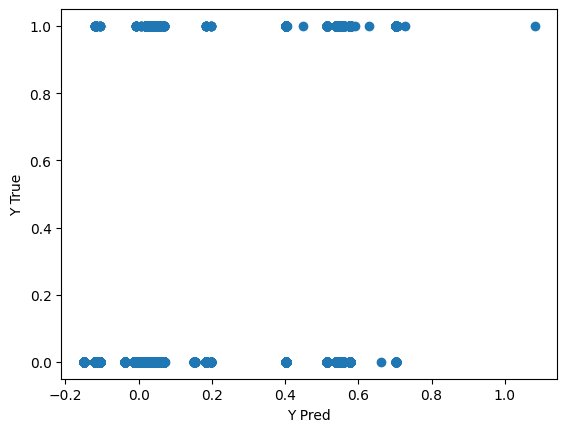

In [229]:
plt.scatter(y_pred, y_resampled)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [230]:
mean_absolute_error(y_true=y_resampled, y_pred=y_pred)

0.1789080017855009

Attempting Polynomial Terms

In [231]:
df_X_with_square = pd.concat((X_resampled, (X_resampled**2).rename(columns = {f"{var}": f"{var}_2" for var in X_resampled.columns})), axis = 1) 
df_X_with_square = sm.add_constant(df_X_with_square) 
model = sm.OLS(y_resampled, df_X_with_square) 
results = model.fit() 
print(results.params)

const                                 0.046619
Amount_Received_USD                   0.003195
Payment Currency_Brazil Real         -0.005301
Payment Currency_Canadian Dollar     -0.007133
Payment Currency_Euro                 0.005185
Payment Currency_Mexican Peso        -0.006444
Payment Currency_Rupee               -0.008019
Payment Currency_Saudi Riyal         -0.005506
Payment Currency_Shekel              -0.008363
Payment Currency_Swiss Franc         -0.008710
Payment Currency_UK Pound            -0.007979
Payment Currency_US Dollar            0.039636
Payment Currency_Yen                 -0.007391
Payment Currency_Yuan                -0.008446
Payment Format_Cash                  -0.032778
Payment Format_Cheque                -0.211588
Payment Format_Credit Card           -0.127657
Payment Format_Reinvestment          -0.033545
Payment Format_Wire                  -0.012322
Is_FX                                 0.046619
const_2                               0.046619
Amount_Receiv

In [232]:
y_pred = results.predict(df_X_with_square)

Text(0, 0.5, 'Y True')

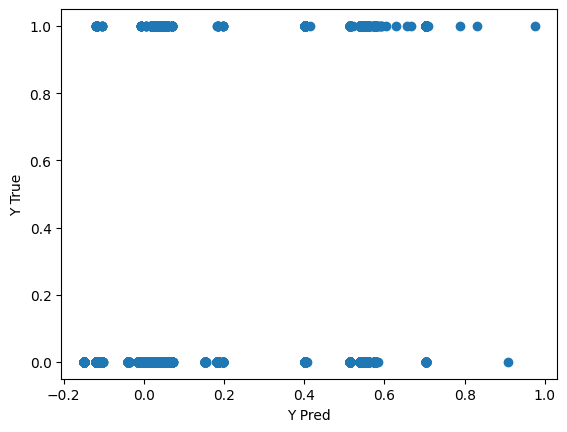

In [233]:
plt.scatter(y_pred, y_resampled)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [234]:
mean_absolute_error(y_true=y_resampled, y_pred=y_pred)

0.17889389251457

This model is actually a bit worse

In [235]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df_X_with_square.columns
vif_data["VIF"] = [variance_inflation_factor(df_X_with_square.values, i) for i in range(df_X_with_square.shape[1])]

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [236]:
len(vif_data.sort_values(by="VIF")[vif_data['VIF'] > 5])

C:\Users\caleb\AppData\Local\Temp\ipykernel_25332\2692098991.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(vif_data.sort_values(by="VIF")[vif_data['VIF'] > 5])


36

36 of the features have VIF > 5, showing multicollinearity. Lets drop them

In [237]:
vif_data = vif_data[vif_data['VIF'] < 5]

In [238]:
len(vif_data['Feature'].values)

4

In [ ]:
df_X_with_square_new = df_X_with_square[vif_data['Feature'].values]

In [ ]:
df_X_with_square_new

,const,V4,V6,V7,V8,V9,V10,V11,V12,V13,...,V15_2,V18_2,V19_2,V22_2,V23_2,V24_2,V25_2,V26_2,V27_2,V28_2
0,1.0,1.378155,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,...,2.155544,0.000665,0.163210,0.077194,0.012204,0.004479,0.016522,0.035764,0.017838,0.000443
1,1.0,0.448154,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,...,0.403934,0.033621,0.021253,0.407902,0.010259,0.115496,0.027946,0.015849,0.000081,0.000217
2,1.0,0.379780,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,...,5.503082,0.014728,5.115998,0.595489,0.827031,0.475108,0.107349,0.019348,0.003064,0.003570
3,1.0,-0.863291,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,...,0.398689,3.864271,1.519357,0.000028,0.036222,1.381977,0.419096,0.049252,0.003934,0.003777
4,1.0,0.403034,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,...,0.030667,0.001459,0.645591,0.637249,0.018895,0.019956,0.042440,0.252297,0.048146,0.046291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.0,-2.066656,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,...,0.854624,0.260745,0.466379,0.012513,1.029169,0.259436,2.064414,0.062517,0.890478,0.678533
284803,1.0,-0.738589,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,...,1.357064,1.491278,2.388744,0.854485,0.000155,1.032715,0.367993,0.156227,0.004688,0.002865
284804,1.0,-0.557828,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,...,1.766995,0.156541,0.333220,0.334349,0.001406,0.409771,0.070621,0.007634,0.000020,0.000705
284805,1.0,0.689799,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,...,3.851654,1.240953,8.397528,0.640078,0.026666,0.015180,0.323942,0.298846,0.011842,0.010927


In [ ]:
model = sm.OLS(y_resampled, df_X_with_square_new) 
results = model.fit() 
print(results.params)

const      0.000738
V4         0.003028
V6        -0.000910
V7        -0.005078
V8         0.001798
V9        -0.003900
V10       -0.007526
V11        0.004422
V12       -0.007634
V13       -0.000570
V14       -0.009517
V15       -0.000024
V16       -0.008143
V17       -0.013777
V18       -0.005379
V19        0.001576
V20        0.000024
V21        0.002189
V22        0.000093
V23       -0.000034
V24       -0.001335
V25       -0.000077
V26        0.001014
V27        0.002329
V28        0.002540
const_2    0.000738
V4_2       0.000210
V9_2       0.000590
V11_2     -0.002170
V13_2      0.000211
V14_2      0.002680
V15_2     -0.000735
V18_2     -0.001408
V19_2     -0.000110
V22_2      0.001539
V23_2      0.000019
V24_2     -0.000809
V25_2     -0.000301
V26_2     -0.000333
V27_2      0.000234
V28_2     -0.000125
dtype: float64


In [ ]:
y_pred = results.predict(df_X_with_square_new)

Text(0, 0.5, 'Y True')

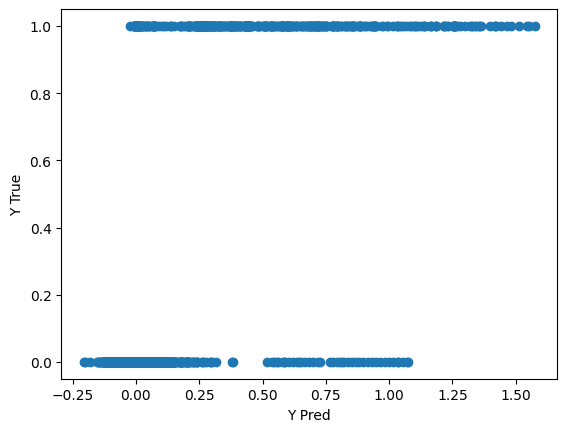

In [ ]:
plt.scatter(y_pred, y_resampled)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [ ]:
mean_absolute_error(y_true=y_resampled, y_pred=y_pred)

ValueError: Found input variables with inconsistent numbers of samples: [31062, 5078345]

### Conclusions